# Attention 到 Transformer Block

> **前情回顾**：上一章你已经知道，Token ID 会先变成 Embedding，再加上 Position。
> **本章目标**：先用 PyTorch 内置 RNN 看见长距离信息的问题，再手写 Attention 和 Transformer Block。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42)

## 1. 为什么 Attention

这一节先回答一个问题：**为什么 Transformer 不继续用 RNN/LSTM？**

先别急着看公式。我们先看旧办法哪里不舒服。


**旧办法：RNN 一步步传话**

RNN 读句子时，是一个词一个词往后传信息。

```
x1 → RNN → h1 → RNN → h2 → RNN → h3 → ...
```

`h` 可以理解成“到目前为止我记住了什么”。


**问题：长距离信息容易丢**

如果句子很长，最前面的信息要传很多步才到后面。

传得越远，越容易丢。

这就像传话游戏：第一句话传 100 次后，通常已经变形了。


**先用实验看见这个问题**

下面这段代码只演示一件事：序列越长，开头位置的梯度越小。

梯度太小，意思就是：模型很难从很远的前文里学到东西。


**实验第 1 步：加载 PyTorch 内置 RNN**

这里先不用手写 RNN 公式。

我们直接使用 `torch.nn.RNN`，让注意力放在实验现象上：最后一个位置的输出，能不能把学习信号传回很早的位置？


In [2]:
# 实验第 1 步：加载 PyTorch 内置 RNN
import matplotlib.pyplot as plt

torch.manual_seed(42)

seq_len = 80
batch_size = 1
input_dim = 4
hidden_dim = 8

rnn = nn.RNN(
    input_size=input_dim,
    hidden_size=hidden_dim,
    num_layers=1,
    nonlinearity="tanh",
    batch_first=True,
)

x = torch.randn(batch_size, seq_len, input_dim, requires_grad=True)

print("=== torch.nn.RNN ===")
print(rnn)
print(f"Input shape: {tuple(x.shape)} = [batch, seq_len, input_dim]")
print("这一步只准备模型和输入。下一步开始观察 hidden state 与梯度。")


=== torch.nn.RNN ===
RNN(4, 8, batch_first=True)
Input shape: (1, 80, 4) = [batch, seq_len, input_dim]
这一步只准备模型和输入。下一步开始观察 hidden state 与梯度。


**实验第 2 步：跑一次前向传播**

`nn.RNN` 会一次吃进整段序列。

它会输出每个位置的 hidden state，以及最后一个 hidden state。


In [3]:
# 实验第 2 步：RNN 前向传播
outputs, h_last = rnn(x)

print("=== Forward pass ===")
print(f"outputs shape: {tuple(outputs.shape)}")
print(f"h_last shape:  {tuple(h_last.shape)}")
print()
print("outputs[:, t, :] 表示第 t 个位置的 hidden state。")
print("h_last 表示最后一步传出来的 hidden state。")


=== Forward pass ===
outputs shape: (1, 80, 8)
h_last shape:  (1, 1, 8)

outputs[:, t, :] 表示第 t 个位置的 hidden state。
h_last 表示最后一步传出来的 hidden state。


**实验第 3 步：从最后一步反向传播**

现在我们只看一个问题：最后一步的输出，对每个输入位置有多敏感？

做法是：把最后一个 hidden state 做成一个 loss，然后 `backward()`。

先不要急着下结论。我们先把几个位置的梯度打印出来，看数值怎么分布。


In [4]:
# 实验第 3 步：打印输入梯度
loss = outputs[:, -1, :].pow(2).mean()
loss.backward()

# 每个时间位置的输入梯度大小：[seq_len]
grad_by_pos = x.grad.norm(dim=-1).squeeze(0)

print("=== Gradients from last output ===")
print(f"loss from last output: {loss.item():.6f}")
print()
for pos in [0, 1, 5, 10, 20, 40, 60, 79]:
    print(f"position {pos:2d} gradient norm: {grad_by_pos[pos].item():.10f}")

first_grad = grad_by_pos[0].item()
middle_grad = grad_by_pos[seq_len // 2].item()
last_grad = grad_by_pos[-1].item()

print()
print("从这次运行结果读数：")
print(f"  开头位置梯度: {first_grad:.3e}")
print(f"  中间位置梯度: {middle_grad:.3e}")
print(f"  最后位置梯度: {last_grad:.3e}")
print()
print("观察：最后一步附近的梯度最大，越往前通常越接近 0。")
print("所以这里能说明的是：最后一步对远处输入的学习信号很弱。")


=== Gradients from last output ===
loss from last output: 0.116176

position  0 gradient norm: 0.0000000000
position  1 gradient norm: 0.0000000000
position  5 gradient norm: 0.0000000000
position 10 gradient norm: 0.0000000000
position 20 gradient norm: 0.0000000000
position 40 gradient norm: 0.0000000006
position 60 gradient norm: 0.0000073567
position 79 gradient norm: 0.0611909442

从这次运行结果读数：
  开头位置梯度: 1.714e-19
  中间位置梯度: 5.538e-10
  最后位置梯度: 6.119e-02

观察：最后一步附近的梯度最大，越往前通常越接近 0。
所以这里能说明的是：最后一步对远处输入的学习信号很弱。


**实验第 4 步：看梯度曲线**

下面这张图画的是输入序列每个位置的梯度大小。

请先看图，再读结论：曲线不是平滑地“慢慢下降”，而是大部分前面位置几乎贴近 0，只有靠近最后的位置明显抬起来。


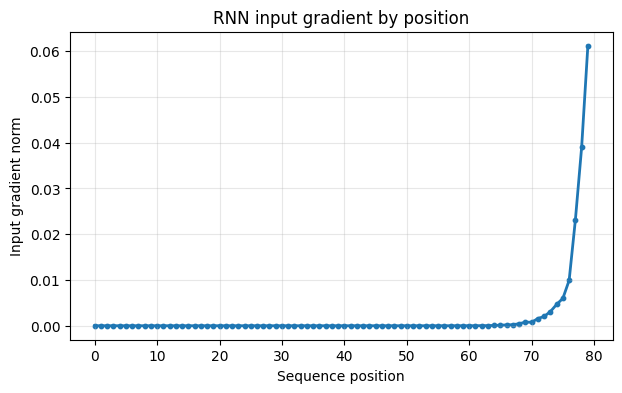

从图上对应的数值看：
  前 5 个位置平均梯度: 7.288e-19
  后 5 个位置平均梯度: 2.784e-02

观察：这次运行里，梯度主要集中在序列末尾附近。
这就是 RNN 学长距离依赖时常见的困难：远处位置收到的学习信号很小。


In [5]:
# 实验第 4 步：RNN 的梯度分布
positions = torch.arange(seq_len)

plt.figure(figsize=(7, 4))
plt.plot(positions.numpy(), grad_by_pos.detach().numpy(), linewidth=2)
plt.scatter(positions.numpy(), grad_by_pos.detach().numpy(), s=10)
plt.xlabel("Sequence position")
plt.ylabel("Input gradient norm")
plt.title("RNN input gradient by position")
plt.grid(True, alpha=0.3)
plt.show()

near_end = grad_by_pos[-5:].mean().item()
far_start = grad_by_pos[:5].mean().item()
print("从图上对应的数值看：")
print(f"  前 5 个位置平均梯度: {far_start:.3e}")
print(f"  后 5 个位置平均梯度: {near_end:.3e}")
print()
print("观察：这次运行里，梯度主要集中在序列末尾附近。")
print("这就是 RNN 学长距离依赖时常见的困难：远处位置收到的学习信号很小。")


**实验第 5 步：序列变长会怎样？**

现在不改 RNN 的权重，只改序列长度。

我们先跑出曲线，再比较每条曲线最左边和最右边的数值。

这张图使用 log 轴。log 轴上差一格，通常就是差很多倍。


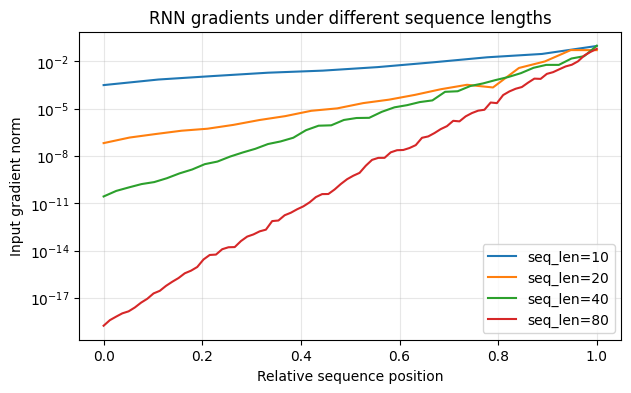

从这次运行结果读数：
  seq_len=10: first=3.068e-04, last=9.274e-02, last/first≈3.023e+02
  seq_len=20: first=6.449e-08, last=5.034e-02, last/first≈7.806e+05
  seq_len=40: first=2.675e-11, last=9.605e-02, last/first≈3.591e+09
  seq_len=80: first=1.714e-19, last=6.119e-02, last/first≈3.570e+17

观察：序列越长，最早位置的梯度通常小到更多数量级。
结论：RNN 不是不能处理序列，而是长距离学习信号更难稳定传回去。
Attention 的核心动机就是：让远处 token 之间少走很多步。


In [6]:
# 实验第 5 步：不同序列长度下的梯度对比
def run_rnn_with_length(length):
    """使用同样配置的 nn.RNN，返回每个位置的输入梯度大小"""
    torch.manual_seed(42)
    model = nn.RNN(input_dim, hidden_dim, nonlinearity="tanh", batch_first=True)
    sample = torch.randn(batch_size, length, input_dim, requires_grad=True)
    out, _ = model(sample)
    loss = out[:, -1, :].pow(2).mean()
    loss.backward()
    return sample.grad.norm(dim=-1).squeeze(0).detach()

lengths = [10, 20, 40, 80]
length_results = {}

plt.figure(figsize=(7, 4))
for length in lengths:
    grads = run_rnn_with_length(length)
    length_results[length] = grads
    relative_pos = torch.linspace(0, 1, steps=length)
    plt.plot(relative_pos.numpy(), grads.numpy(), label=f"seq_len={length}")

plt.xlabel("Relative sequence position")
plt.ylabel("Input gradient norm")
plt.title("RNN gradients under different sequence lengths")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("从这次运行结果读数：")
for length in lengths:
    grads = length_results[length]
    first = grads[0].item()
    last = grads[-1].item()
    ratio = last / max(first, 1e-30)
    print(f"  seq_len={length:2d}: first={first:.3e}, last={last:.3e}, last/first≈{ratio:.3e}")

print()
print("观察：序列越长，最早位置的梯度通常小到更多数量级。")
print("结论：RNN 不是不能处理序列，而是长距离学习信号更难稳定传回去。")
print("Attention 的核心动机就是：让远处 token 之间少走很多步。")


**Attention 的答案：直接看**

RNN 的路径是这样：

```
第 1 个词 → 传 → 传 → 传 → 第 100 个词
```

Attention 的路径是这样：

```
第 100 个词 → 直接看 → 第 1 个词
```


**直接看带来三个好处**

- 远距离信息不需要传很多步
- 训练时可以并行计算
- attention 权重能告诉你模型更关注谁

所以先记住一句话：**Attention 让每个 token 直接看其他 token。**


## 2. Attention 直觉

先用一句话建立画面：**每个 token 都会问：我现在应该看谁？**


**例子：sat 应该看谁？**

假设模型看到：`The cat sat on the mat`。

当它处理 `sat` 时，应该更关注：

- `cat`：谁在坐？
- `mat`：坐在哪里？
- `the`：关系弱一些


**Attention weight 就是关注比例**

```
      The  cat  sat  on  the  mat
sat: 0.05 0.35 0.10 0.05 0.05 0.40
```

`cat` 和 `mat` 权重大，说明 `sat` 更需要它们的信息。


### Q K V

Q/K/V 是 Attention 里最重要的三个角色。

先不要背公式，把它们当成三个问题。


**Q：我想找什么？**

Q 是 Query。

比如 `sat` 这个 token 可能在问：谁在做这个动作？动作发生在哪里？


**K：我是什么标签？**

K 是 Key。

每个 token 都拿出自己的“标签”，让别人判断要不要关注我。


**V：我能提供什么信息？**

V 是 Value。

如果某个 token 被关注，它真正传出去的是 V 里的信息。


**Q/K/V 合起来怎么用？**

1. 用 Q 去匹配所有 K，算相关度
2. 把相关度变成权重
3. 用权重混合所有 V

在 Self-Attention 里，每个 token 同时有 Q、K、V 三个身份。


### X 从哪来

在算 Q/K/V 之前，先弄清楚输入矩阵 `X` 是什么。


**X 是一整句话的向量表**

完整链路是：

```
"the cat sat"
   ↓ Tokenizer
[2, 5, 8]
   ↓ Embedding
X = [[...],
     [...],
     [...]]
```

每一行是一个 token 的向量。


**Q/K/V 都从 X 来**

后面你会看到：

```
Q = X @ W_Q
K = X @ W_K
V = X @ W_V
```

也就是说，同一个输入 `X`，乘三个不同矩阵，变成三种角色。


In [7]:
# === 词表 → 句子 → Token IDs → Embedding 查表 → X ===
vocab = {"the": 0, "a": 1, "cat": 2, "dog": 3, "sat": 4,
         "ran": 5, "on": 6, "mat": 7, "[PAD]": 8, "[UNK]": 9}
vocab_size = len(vocab)
id2word = {v: k for k, v in vocab.items()}

# 句子 → token ids
sentence = ["the", "cat", "sat"]
token_ids = [vocab[w] for w in sentence]  # [0, 2, 4]

# token ids → Embedding 查表 → X
d_model = 4
embedding = nn.Embedding(vocab_size, d_model)
token_ids_tensor = torch.tensor(token_ids)  # [3]
X = embedding(token_ids_tensor)             # [3, 4]

print(f"词表大小: {vocab_size}, 句子: {' '.join(sentence)}")
print(f"Token IDs: {token_ids}")
print(f"X 形状: {list(X.shape)}  ← [seq_len=3, d_model=4]")
print(f"\nX = (来自 Embedding 查表，不是 randn):\n{X}")
print(f"\n解释: X[0]='the' → {X[0].tolist()}")
print(f"      X[1]='cat' → {X[1].tolist()}")
print(f"      X[2]='sat' → {X[2].tolist()}")

词表大小: 10, 句子: the cat sat
Token IDs: [0, 2, 4]
X 形状: [3, 4]  ← [seq_len=3, d_model=4]

X = (来自 Embedding 查表，不是 randn):
tensor([[-0.4940,  1.1366, -0.4618,  1.4200],
        [ 0.6899, -1.3129,  0.0378, -1.1702],
        [-1.3839,  0.4869, -1.0020,  0.0329]], grad_fn=<EmbeddingBackward0>)

解释: X[0]='the' → [-0.4939991533756256, 1.1366126537322998, -0.46184006333351135, 1.419979453086853]
      X[1]='cat' → [0.6899018287658691, -1.3129348754882812, 0.037803765386343, -1.1702114343643188]
      X[2]='sat' → [-1.3838841915130615, 0.4868715703487396, -1.0020296573638916, 0.0329488143324852]


In [8]:
# === 从上一步的 X 出发，计算 Q/K/V ===
seq_len = X.shape[0]  # = 3
d_k = 4

# Q/K/V 都来自 X，但各自乘不同的权重矩阵（用 nn.Linear，和后面 MHA 一致）
W_Q = nn.Linear(d_model, d_k, bias=False)
W_K = nn.Linear(d_model, d_k, bias=False)
W_V = nn.Linear(d_model, d_k, bias=False)

Q = W_Q(X)  # [3, 4] — 每个 token 的「查询」
K = W_K(X)  # [3, 4] — 每个 token 的「标签」
V = W_V(X)  # [3, 4] — 每个 token 的「内容」

print(f"X 形状: {X.shape}  →  Q/K/V 形状: {Q.shape}")
print(f"→ Q、K、V 都来自同一个 X，乘了不同的矩阵")

X 形状: torch.Size([3, 4])  →  Q/K/V 形状: torch.Size([3, 4])
→ Q、K、V 都来自同一个 X，乘了不同的矩阵


## 3. 手算 Attention

接下来只做一件事：把 Attention 的计算拆成四小步。


### 算分数

第一步是算 `Q × K^T`。

第 i 行、第 j 列表示：**token i 对 token j 有多感兴趣。**

```
scores[i, j] = Q_i · K_j
```

点积越大，说明匹配越强。


In [9]:
# Step 1: 注意力分数 = Q × K^T
# 第 i 行第 j 列 = token i 对 token j 的原始相关度
attention_scores = Q @ K.T  # [3, 4] @ [4, 3] = [3, 3]

print(f"注意力分数矩阵 {list(attention_scores.shape)} = [{seq_len}×{seq_len}]:")
print(attention_scores)
print(f"\n第 i 行 = token {list(range(seq_len))} 对各 token 的分数")

注意力分数矩阵 [3, 3] = [3×3]:
tensor([[-0.5061,  0.5983, -0.3896],
        [ 0.4498, -0.5545,  0.3047],
        [ 0.0982, -0.1379,  0.0504]], grad_fn=<MmBackward0>)

第 i 行 = token [0, 1, 2] 对各 token 的分数


**缩放**

点积结果可能很大。数值太大时，softmax 会变得过于自信，训练不稳定。

所以要除以 `√d_k`，让分数更稳。


In [10]:
# Step 2: 缩放 / √d_k  → 防止 d_k 大时点积过大，softmax 梯度消失
d_k = Q.shape[-1]
scaled_scores = attention_scores / math.sqrt(d_k)

print(f"缩放因子: √{d_k} = {math.sqrt(d_k):.2f}")
print(f"缩放前 token 0: {attention_scores[0].tolist()}")
print(f"缩放后 token 0: {scaled_scores[0].tolist()}  ← 值变小，相对大小不变")

缩放因子: √4 = 2.00
缩放前 token 0: [-0.5061002373695374, 0.5982879996299744, -0.38956695795059204]
缩放后 token 0: [-0.2530501186847687, 0.2991439998149872, -0.19478347897529602]  ← 值变小，相对大小不变


**Softmax**

softmax 把一行分数变成概率：

```
softmax([2, 3, 1]) → [0.24, 0.67, 0.09]
```

每一行加起来等于 1，表示这个 token 对其他 token 的关注比例。


In [11]:
# Step 3: Softmax → 把分数变成概率（每行加起来 = 1）
attention_weights = F.softmax(scaled_scores, dim=-1)

print(f"注意力权重矩阵 {list(attention_weights.shape)}:")
print(attention_weights)

# 验证每行和为 1
print(f"\n每行和: {attention_weights.sum(dim=-1).tolist()}  ← 都是 1.0")

注意力权重矩阵 [3, 3]:
tensor([[0.2634, 0.4575, 0.2792],
        [0.3944, 0.2387, 0.3668],
        [0.3490, 0.3102, 0.3408]], grad_fn=<SoftmaxBackward0>)

每行和: [1.0, 1.0000001192092896, 1.0]  ← 都是 1.0


**加权求和**

最后用权重去混合 V。

谁权重大，谁的信息就进来得多。这样每个 token 的输出，就融合了它关注到的上下文。


In [12]:
# Step 4: 加权求和 — 用注意力权重混合 V
output = attention_weights @ V  # [3, 3] @ [3, 4] = [3, 4]

print(f"输出形状: {list(output.shape)} = [{seq_len}, {d_model}]")
print(f"\n输入  token 0: {X[0].tolist()}")
print(f"输出 token 0: {output[0].tolist()}")
print(f"→ 不一样！因为 token 0 按权重融合了 token 1、2 的信息")

输出形状: [3, 4] = [3, 4]

输入  token 0: [-0.4939991533756256, 1.1366126537322998, -0.46184006333351135, 1.419979453086853]
输出 token 0: [-0.07001280039548874, -0.08906019479036331, -0.04958437383174896, -0.19187720119953156]
→ 不一样！因为 token 0 按权重融合了 token 1、2 的信息


### 四步法

把刚才的手算压缩成一张小抄。


**Attention 的 4 步**

```
1. Q = X @ W_Q, K = X @ W_K, V = X @ W_V
2. scores = Q @ K^T
3. weights = softmax(scores / √d_k)
4. output = weights @ V
```

这就是 Scaled Dot-Product Attention。


## 4. Causal Mask

GPT 是生成模型，所以它预测下一个 token 时不能偷看未来。


**为什么要遮住未来？**

比如预测 `cat` 后面的词，模型不能提前看到答案 `sat`。

否则训练就像考试偷看答案，loss 会很好看，但模型其实没学会生成。


**怎么遮？**

在 softmax 前，把未来位置的分数变成 `-∞`。

```
[a, b, c]  →  [a, -∞, -∞]
[d, e, f]  →  [d,  e, -∞]
[g, h, i]  →  [g,  h,  i]
```

softmax 后，`-∞` 对应的位置会变成 0。


In [13]:
# Causal mask：下三角矩阵，1=允许看，0=遮住（→ -inf）
def causal_mask(seq_len):
    return torch.tril(torch.ones(seq_len, seq_len))

mask = causal_mask(5)
print("Causal Mask (1=允许看, 0=不允许):")
print(mask)
# 第 i 行 = token i 能看到的位置：token 0 只看 [0]，token 2 看 [0,1,2]

Causal Mask (1=允许看, 0=不允许):
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])


## 5. Multi-Head

单头 Attention 只有一个视角。


**为什么要多个头？**

同一句话可以从不同角度看：

```
头 1：可能看语法关系
头 2：可能看远近位置
头 3：可能看语义关系
```

多个头并行看，模型就不容易只盯住一种关系。


**多头最后要合并**

每个头先各自算 Attention。

然后把多个头的结果拼起来，再过一层线性变换。

你可以把它想成：几个读者同时做笔记，最后把笔记合成一份。


In [14]:
class MultiHeadAttention(nn.Module):
    """
    多头因果自注意力
    
    参数:
        d_model: 输入/输出维度
        num_heads: 注意力头数
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度
        
        # Q、K、V 的线性变换（把 num_heads 个头合并到矩阵操作里）
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        
        # 输出投影
        self.W_O = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        """
        输入: x shape = [batch, seq_len, d_model]
        输出:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape
        
        # 1. 线性变换 + 拆成多头
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. 注意力分数: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 3. Mask（把未来的位置设为 -inf）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # 4. Softmax
        weights = F.softmax(scores, dim=-1)
        
        # 5. 加权求和
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]
        
        # 6. 拼回头并投影
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


In [15]:
# 测试多头注意力
d_model, num_heads = 8, 2
mha = MultiHeadAttention(d_model, num_heads)

test_x = torch.randn(1, 5, d_model)                         # batch=1, 5 token, 8 维
test_mask = causal_mask(5).unsqueeze(0).unsqueeze(0)        # [1, 1, 5, 5]

out = mha(test_x, test_mask)
print(f"输入: {test_x.shape}  →  输出: {out.shape}  ← 形状不变，内容融合了全局注意力")

输入: torch.Size([1, 5, 8])  →  输出: torch.Size([1, 5, 8])  ← 形状不变，内容融合了全局注意力


## 6. Transformer Block

一个 Transformer Block 不要一次看成一大坨。

它其实是几个小零件串起来。


**零件 1：Attention**

Multi-Head Self-Attention 负责让 token 互相看。

它解决的是“上下文信息怎么流动”的问题。


**零件 2：FFN**

Feed-Forward Network 对每个位置单独做更深的变换。

它解决的是“看完上下文后，怎么加工这个位置的信息”。


**技巧 1：Residual**

Residual 的意思是：

```
输出 = 输入 + 子层输出
```

这样深层网络更容易训练，因为原始信息有一条直通路。


**技巧 2：LayerNorm**

LayerNorm 会把每层的数值拉回稳定范围。

它解决的是“层数变多后，数值别乱飞”的问题。


**Block 小抄**

```
x → Attention → Add & Norm → FFN → Add & Norm
```

先会看，再加工；中间用 Residual 和 LayerNorm 保持训练稳定。


In [16]:
class FeedForward(nn.Module):
    """FFN：两层全连接，先扩 4 倍再压回"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """一个 Transformer 解码器层：Attention + FFN，各带残差 + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # Attention + 残差 + Norm
        x = self.norm2(x + self.ffn(x))              # FFN + 残差 + Norm
        return x

# 测试
block = TransformerBlock(d_model=8, num_heads=2)
test_out = block(test_x, test_mask)
print(f"TransformerBlock 输入: {test_x.shape}  →  输出: {test_out.shape}  ← 形状不变")

TransformerBlock 输入: torch.Size([1, 5, 8])  →  输出: torch.Size([1, 5, 8])  ← 形状不变


---

## 小结

确认你已经懂了这些：

1. ✅ RNN 是一步步传话，远处信息容易在很多步之后变弱
2. ✅ Attention 让每个 token 直接看其他 token
3. ✅ Q 是查询，K 是标签，V 是内容
4. ✅ Attention 四步：算分数 → 缩放 → softmax → 加权求和
5. ✅ Causal Mask 让 GPT 不能偷看未来
6. ✅ Multi-Head 是多个视角并行看
7. ✅ Transformer Block = Attention + FFN + Residual + LayerNorm

下一章：把 Transformer Block 堆起来，跟着 GPT-2 的结构图手写一个 Mini-GPT。


---

## 本章作业：Attention

这两题只检查最核心的骨架：Attention score 和 causal mask。

> **使用 AI 的注意事项**：可以让 AI 解释 shape，但不要让它直接替你填答案。你亲手把张量接起来，才会真的记住。


### 作业 1：核心机制 —— Attention score

Attention 的第一步是用 query 和 key 算相关性分数。

**小提示**：两个向量点积可以用 `(q * k).sum()`。


In [ ]:
# 作业 1：Attention score 填空
import torch

q = torch.tensor([1.0, 2.0, 0.0])
k = torch.tensor([3.0, 1.0, 4.0])

# TODO：把下面三引号里的内容替换成你的代码
score = """在这里计算 q 和 k 的点积"""

assert not isinstance(score, str), "请先替换三引号里的占位内容"
assert score.item() == 5.0, score
print("✅ 作业 1 通过：你记住了 attention score 的核心是 QK 点积")


### 作业 2：核心机制 —— causal mask

GPT 生成时不能偷看未来 token，所以位置 `i` 只能看 `0...i`。

**小提示**：`torch.tril(torch.ones(seq_len, seq_len))` 会生成下三角矩阵。


In [ ]:
# 作业 2：Causal Mask 填空
import torch

seq_len = 5

# TODO：生成一个 5x5 的下三角 causal mask
mask = """在这里生成 causal mask"""

expected = torch.tensor([
    [1, 0, 0, 0, 0],
    [1, 1, 0, 0, 0],
    [1, 1, 1, 0, 0],
    [1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1],
])
assert not isinstance(mask, str), "请先替换三引号里的占位内容"
assert torch.equal(mask, expected), mask
print("✅ 作业 2 通过：你理解了 GPT 为什么只能看过去")
